### Imports

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from analysis import compute_psd, parse_rr, calc_stress


### Load sambo data

#### Andrey

In [60]:
andr_path = r'C:\analysis_HVR\raw_data\sambo\andrey'
header = ['№','ЧССmin, уд./мин.','ЧССmax, уд./мин.','ЧССavg, уд./мин.','Стресс НС, %','SDNN, мс','ИН, у.е.','Mo, мс','RMSSD, мс','NN50, пар','pNN50, %','HF, мс²/Гц','TP, мс²/Гц','LF, мс²/Гц','LF/HF, у.е.','VLF, мс²/Гц','Дата обследования']
df_andr = pd.read_csv(andr_path+r'\Lebedev_Andrey_Mikhaylovich.csv',sep=';',skiprows=1,header=None,encoding_errors='replace',encoding='utf-8',comment='#')
df_andr.columns = header
df_andr['Дата обследования'] = pd.to_datetime(df_andr['Дата обследования'])
df_andr['name'] = 'andr'
df_andr.head()

C:\Users\User\AppData\Local\Temp\ipykernel_18252\1858364974.py:5: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_andr['Дата обследования'] = pd.to_datetime(df_andr['Дата обследования'])


,№,"ЧССmin, уд./мин.","ЧССmax, уд./мин.","ЧССavg, уд./мин.","Стресс НС, %","SDNN, мс","ИН, у.е.","Mo, мс","RMSSD, мс","NN50, пар","pNN50, %","HF, мс²/Гц","TP, мс²/Гц","LF, мс²/Гц","LF/HF, у.е.","VLF, мс²/Гц",Дата обследования,name
0,1,63.0,88.0,75.0,"50,8",55,"62,7",760.0,"45,1",108.0,"29,3",397.0,2638.0,924.0,"2,33",1317.0,2026-08-24 09:05:00,andr
1,2,54.0,78.0,63.0,"39,3","70,2","36,9",960.0,"56,7",99.0,"32,6",755.0,4755.0,2006.0,"2,66",1994.0,2026-08-20 09:15:00,andr
2,3,56.0,83.0,64.0,"69,4","68,4","46,9",920.0,"37,7",57.0,18,203.0,4274.0,1093.0,"5,38",2978.0,2026-08-19 09:01:00,andr
3,4,59.0,71.0,64.0,"27,2","30,3","175,3",920.0,"24,3",8.0,"2,5",172.0,779.0,396.0,"2,29",211.0,2026-08-18 09:06:00,andr
4,5,58.0,70.0,63.0,"68,2","33,4","151,5",920.0,"33,2",41.0,"13,6",212.0,877.0,249.0,"1,17",416.0,2026-08-17 09:00:00,andr


#### Konst

In [61]:
konst_path = r'C:\analysis_HVR\raw_data\sambo\konstantin'
header = ['№','ЧССmin, уд./мин.','ЧССmax, уд./мин.','ЧССavg, уд./мин.','Стресс НС, %','SDNN, мс','ИН, у.е.','Mo, мс','RMSSD, мс','NN50, пар','pNN50, %','HF, мс²/Гц','TP, мс²/Гц','LF, мс²/Гц','LF/HF, у.е.','VLF, мс²/Гц','Дата обследования']
df_konst = pd.read_csv(konst_path+r'\Buzmakov_Konstantin_Alexeevich.csv',parse_dates=True,sep=';',skiprows=1,header=None,encoding_errors='replace',encoding='utf-8')
df_konst.columns = header
df_konst['Дата обследования'] = pd.to_datetime(df_konst['Дата обследования'])
df_konst['name'] = 'konst'
df_konst.head()

C:\Users\User\AppData\Local\Temp\ipykernel_18252\1694071342.py:5: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_konst['Дата обследования'] = pd.to_datetime(df_konst['Дата обследования'])


,№,"ЧССmin, уд./мин.","ЧССmax, уд./мин.","ЧССavg, уд./мин.","Стресс НС, %","SDNN, мс","ИН, у.е.","Mo, мс","RMSSD, мс","NN50, пар","pNN50, %","HF, мс²/Гц","TP, мс²/Гц","LF, мс²/Гц","LF/HF, у.е.","VLF, мс²/Гц",Дата обследования,name
0,1,80,107,92,"40,6","32,4","193,2",640,"21,7",13,"2,8",182,992,317,"1,74",493,2026-08-19 08:49:00,konst
1,2,60,82,67,"53,7","51,9","83,8",880,"46,1",65,"20,3",819,2562,914,"1,12",829,2026-08-18 09:05:00,konst
2,3,72,122,95,"51,2","69,4","51,6",560,"35,6",54,"11,6",429,4176,1710,"3,99",2037,2026-08-17 08:54:00,konst
3,4,72,120,85,"71,3","73,8","53,9",720,"30,1",39,"9,3",251,4275,1044,"4,16",2979,2026-08-15 09:07:00,konst
4,5,69,115,88,"59,9","80,2","37,6",680,"43,8",82,19,616,6783,2494,"4,05",3672,2026-08-14 08:59:00,konst


#### Fillip

In [62]:
filipp_path = r'C:\analysis_HVR\raw_data\sambo\filipp'
header = ['№','ЧССmin, уд./мин.','ЧССmax, уд./мин.','ЧССavg, уд./мин.','Стресс НС, %','SDNN, мс','ИН, у.е.','Mo, мс','RMSSD, мс','NN50, пар','pNN50, %','HF, мс²/Гц','TP, мс²/Гц','LF, мс²/Гц','LF/HF, у.е.','VLF, мс²/Гц','Дата обследования']
df_fil = pd.read_csv(filipp_path+r'\Kazakov_Filipp_Alexandrovich.csv',parse_dates=True,sep=';',skiprows=1,header=None,encoding_errors='replace',encoding='utf-8')
df_fil.columns = header
df_fil['Дата обследования'] = pd.to_datetime(df_fil['Дата обследования'])
df_fil['name'] = 'fil'

df_fil.head()

C:\Users\User\AppData\Local\Temp\ipykernel_18252\3488118422.py:5: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_fil['Дата обследования'] = pd.to_datetime(df_fil['Дата обследования'])


,№,"ЧССmin, уд./мин.","ЧССmax, уд./мин.","ЧССavg, уд./мин.","Стресс НС, %","SDNN, мс","ИН, у.е.","Mo, мс","RMSSD, мс","NN50, пар","pNN50, %","HF, мс²/Гц","TP, мс²/Гц","LF, мс²/Гц","LF/HF, у.е.","VLF, мс²/Гц",Дата обследования,name
0,1,72,112,89,"60,6","56,4",69,680,"34,5",64,"14,3",411,2544,821,2,1313,2026-08-26 09:51:00,fil
1,2,66,98,80,72,"64,4","58,3",760,"34,1",47,"11,9",468,2871,971,"2,07",1432,2026-08-25 09:18:00,fil
2,3,58,99,76,"62,6","94,3","25,1",720,"49,8",96,"26,2",779,8524,2102,"2,7",5643,2026-08-24 09:04:00,fil
3,4,52,92,65,"65,4","117,6","19,6",880,"80,1",150,"50,5",2834,13633,3544,"1,25",7255,2026-08-22 09:05:00,fil
4,5,64,98,77,"66,9","65,5","54,2",760,"38,2",61,"13,6",528,3460,915,"1,73",2017,2026-08-21 10:01:00,fil


#### Trofim

In [63]:
trofim_path = r'C:\analysis_HVR\raw_data\sambo\trofim'
header = ['№','ЧССmin, уд./мин.','ЧССmax, уд./мин.','ЧССavg, уд./мин.','Стресс НС, %','SDNN, мс','ИН, у.е.','Mo, мс','RMSSD, мс','NN50, пар','pNN50, %','HF, мс²/Гц','TP, мс²/Гц','LF, мс²/Гц','LF/HF, у.е.','VLF, мс²/Гц','Дата обследования']
df_trofim = pd.read_csv(trofim_path+r'\Kazakov_Trofim_Alexandrovich.csv',parse_dates=True,sep=';',skiprows=1,header=None,encoding_errors='replace',encoding='utf-8')
df_trofim.columns = header
df_trofim['Дата обследования'] = pd.to_datetime(df_trofim['Дата обследования'])
df_trofim['name'] = 'trofim'
df_trofim.head()

C:\Users\User\AppData\Local\Temp\ipykernel_18252\1877464263.py:5: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_trofim['Дата обследования'] = pd.to_datetime(df_trofim['Дата обследования'])


,№,"ЧССmin, уд./мин.","ЧССmax, уд./мин.","ЧССavg, уд./мин.","Стресс НС, %","SDNN, мс","ИН, у.е.","Mo, мс","RMSSD, мс","NN50, пар","pNN50, %","HF, мс²/Гц","TP, мс²/Гц","LF, мс²/Гц","LF/HF, у.е.","VLF, мс²/Гц",Дата обследования,name
0,1,66,112,84,"45,7","92,6","29,9",680,"40,3",79,"19,2",457,8281,2486,"5,44",5338,2026-08-26 09:51:00,trofim
1,2,66,107,82,"39,9","71,8","48,9",720,"63,5",131,"39,8",1386,4905,1404,"1,01",2115,2026-08-25 09:19:00,trofim
2,3,75,104,90,"46,5","41,7","127,2",640,"35,6",64,"15,4",482,1692,503,"1,04",707,2026-08-24 09:08:00,trofim
3,4,72,99,84,"51,7","49,8","91,2",720,"35,2",69,"16,5",425,2224,700,"1,65",1100,2026-08-22 10:17:00,trofim
4,5,72,107,87,"62,8",50,"90,5",680,"29,2",32,"7,4",378,2545,627,"1,66",1540,2026-08-21 11:04:00,trofim


#### import analysis.py

In [64]:
def parse_header(raw_data):
    """Извлекает метаданные из блока [Header] в виде словаря."""
    lines = raw_data.split('\n')
    in_header = False
    header_data = {}
    
    for line in lines:
        line = line.strip()
        
        # Проверяем начало блока (приводим к нижнему регистру для надежности)
        if line.lower() == '[header]':
            in_header = True
            continue
            
        # Если встретили следующий блок, выходим из режима чтения хедера
        if line.startswith('['):
            in_header = False
            continue
            
        # Парсим ключ=значение внутри блока
        if in_header and line and '=' in line:
            key, val = line.split('=', 1)  # разделяем только по первому знаку "="
            header_data[key.strip()] = val.strip()
            
    return header_data


In [65]:
file_path = r'C:\analysis_HVR\raw_data\sambo\andrey\84E5FD2B_2026_08_17_09_00_09_teamloggerh10.teamloggerh10'
with open(file_path,'r') as f:
    raw_text = f.read()
date = parse_header(raw_text)['datetime']
rr = parse_rr(raw_text)
tp = compute_psd(rr)[-1]['tp']
print(tp)

1764.0838702969365


Andrey files:

In [66]:
import os
def clear_and_calc_tp(path, df):
    entries = os.listdir(path)
    # Фильтруем только файлы (без директорий)
    files = [entry for entry in entries if os.path.isfile(os.path.join(path, entry))]
    # Фильтруем по расширению
    csv_files = [file for file in files if file.endswith('.teamloggerh10')]
    for file in csv_files:
        with open(path + os.sep + file,'r') as f:
            raw_text = f.read()
        date = pd.to_datetime(parse_header(raw_text)['datetime'])
        rr = parse_rr(raw_text)
        
        if len(df.loc[(df['Дата обследования'].dt.date == date.date()) & (df['Дата обследования'].dt.hour == date.hour) & (df['Дата обследования'].dt.minute == date.minute)]) != 0:

            tp = compute_psd(rr)[-1]['tp']    
            df.loc[
                (df['Дата обследования'].dt.date == date.date()) & 
                (df['Дата обследования'].dt.hour == date.hour) & 
                (df['Дата обследования'].dt.minute == date.minute),'Рассчитанный TP'] = tp

            si = calc_stress(rr)['si']
            df.loc[
                (df['Дата обследования'].dt.date == date.date()) & 
                (df['Дата обследования'].dt.hour == date.hour) & 
                (df['Дата обследования'].dt.minute == date.minute),'Рассчитанный SI'] = si
        else:
            print(f'file {file} not in report')

In [67]:
clear_and_calc_tp(andr_path,df_andr)

In [68]:
clear_and_calc_tp(filipp_path,df_fil)

file C821EB2E_2026_08_03_08_45_28_teamloggerh10.teamloggerh10 not in report
file C821EB2E_2026_teamloggerh10_10_teamloggerh10.teamloggerh10 not in report


In [69]:
clear_and_calc_tp(konst_path,df_konst)

file C821E528_2026_08_08_08_47_04_teamloggerh10.teamloggerh10 not in report
file C821EB2E_2026_teamloggerh10_2_teamloggerh10.teamloggerh10 not in report


In [70]:
clear_and_calc_tp(trofim_path,df_trofim)

In [71]:
df_fil

,№,"ЧССmin, уд./мин.","ЧССmax, уд./мин.","ЧССavg, уд./мин.","Стресс НС, %","SDNN, мс","ИН, у.е.","Mo, мс","RMSSD, мс","NN50, пар","pNN50, %","HF, мс²/Гц","TP, мс²/Гц","LF, мс²/Гц","LF/HF, у.е.","VLF, мс²/Гц",Дата обследования,name,Рассчитанный TP,Рассчитанный SI
0,1,72,112,89,"60,6","56,4",69,680,"34,5",64,"14,3",411,2544,821,2,1313,2026-08-26 09:51:00,fil,2640.426330,86.733612
1,2,66,98,80,72,"64,4","58,3",760,"34,1",47,"11,9",468,2871,971,"2,07",1432,2026-08-25 09:18:00,fil,3021.440977,45.737012
2,3,58,99,76,"62,6","94,3","25,1",720,"49,8",96,"26,2",779,8524,2102,"2,7",5643,2026-08-24 09:04:00,fil,11207.696341,20.110336
3,4,52,92,65,"65,4","117,6","19,6",880,"80,1",150,"50,5",2834,13633,3544,"1,25",7255,2026-08-22 09:05:00,fil,13631.525363,15.223072
4,5,64,98,77,"66,9","65,5","54,2",760,"38,2",61,"13,6",528,3460,915,"1,73",2017,2026-08-21 10:01:00,fil,2209.400714,106.931078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,178,52,83,65,"18,6","95,5","19,2",920,"123,4",187,"64,3",4004,7693,3161,"0,79",529,2023-12-28 08:07:00,fil,NaN,NaN
178,179,52,82,65,"16,3","95,3","23,4",920,"116,6",176,"62,6",3651,7802,3490,"0,96",662,2023-12-28 08:07:00,fil,NaN,NaN
179,180,63,93,76,"33,6","66,3","57,4",760,"64,5",133,"39,7",1224,4061,2128,"1,74",708,2023-12-26 09:35:00,fil,NaN,NaN
180,181,63,93,75,"24,9","66,1","48,3",760,"65,9",111,38,1245,4092,2299,"1,85",547,2023-12-26 09:35:00,fil,NaN,NaN


In [72]:
all_df = pd.concat([df_trofim,df_konst,df_andr,df_fil],axis=0)

In [73]:
all_df = all_df.dropna()

In [74]:
all_df['Стресс НС, %'] = pd.to_numeric(all_df['Стресс НС, %'].str.replace(r',', '.', regex=True))

In [75]:
all_df

,№,"ЧССmin, уд./мин.","ЧССmax, уд./мин.","ЧССavg, уд./мин.","Стресс НС, %","SDNN, мс","ИН, у.е.","Mo, мс","RMSSD, мс","NN50, пар","pNN50, %","HF, мс²/Гц","TP, мс²/Гц","LF, мс²/Гц","LF/HF, у.е.","VLF, мс²/Гц",Дата обследования,name,Рассчитанный TP,Рассчитанный SI
0,1,66.0,112.0,84.0,45.7,"92,6","29,9",680.0,"40,3",79.0,"19,2",457.0,8281.0,2486.0,"5,44",5338.0,2026-08-26 09:51:00,trofim,6465.595313,31.251713
1,2,66.0,107.0,82.0,39.9,"71,8","48,9",720.0,"63,5",131.0,"39,8",1386.0,4905.0,1404.0,"1,01",2115.0,2026-08-25 09:19:00,trofim,3387.744399,60.013046
2,3,75.0,104.0,90.0,46.5,"41,7","127,2",640.0,"35,6",64.0,"15,4",482.0,1692.0,503.0,"1,04",707.0,2026-08-24 09:08:00,trofim,1487.922991,133.777461
3,4,72.0,99.0,84.0,51.7,"49,8","91,2",720.0,"35,2",69.0,"16,5",425.0,2224.0,700.0,"1,65",1100.0,2026-08-22 10:17:00,trofim,2229.942885,91.703348
4,5,72.0,107.0,87.0,62.8,50,"90,5",680.0,"29,2",32.0,"7,4",378.0,2545.0,627.0,"1,66",1540.0,2026-08-21 11:04:00,trofim,1541.931508,84.206981
5,6,63.0,106.0,80.0,54.5,87,33,680.0,"75,7",195.0,"51,2",2511.0,6260.0,1804.0,"0,72",1945.0,2026-08-20 09:15:00,trofim,5524.947706,38.904451
6,7,58.0,88.0,72.0,41.5,"85,4","35,3",800.0,"78,6",169.0,"50,4",2320.0,6817.0,2314.0,1,2184.0,2026-08-19 08:50:00,trofim,8626.830485,21.082463
7,8,69.0,96.0,80.0,39.9,"55,3","82,6",720.0,"41,4",89.0,"22,7",684.0,2709.0,979.0,"1,43",1046.0,2026-08-18 08:54:00,trofim,1396.831899,116.352686
8,9,62.0,102.0,81.0,26.0,"80,5",42,720.0,"87,7",73.0,"52,5",1727.0,5648.0,2325.0,"1,35",1596.0,2026-08-17 09:14:00,trofim,5194.842202,22.431317
9,10,54.0,94.0,71.0,38.5,"115,2","18,8",720.0,100,168.0,"54,9",3899.0,12362.0,5191.0,"1,33",3272.0,2026-08-15 09:14:00,trofim,18827.288366,15.253549


In [76]:
all_df[all_df['TP, мс²/Гц'] > 35000]

,№,"ЧССmin, уд./мин.","ЧССmax, уд./мин.","ЧССavg, уд./мин.","Стресс НС, %","SDNN, мс","ИН, у.е.","Mo, мс","RMSSD, мс","NN50, пар","pNN50, %","HF, мс²/Гц","TP, мс²/Гц","LF, мс²/Гц","LF/HF, у.е.","VLF, мс²/Гц",Дата обследования,name,Рассчитанный TP,Рассчитанный SI
14,15,43.0,94.0,60.0,71.8,"206,4","6,5",920.0,"167,5",152.0,"69,1",9743.0,42578.0,8598.0,"0,88",24237.0,2026-08-10 08:33:00,fil,2307.630627,33.337199


In [77]:
all_df = all_df[all_df['TP, мс²/Гц']< 30000]

In [78]:
print(f"""
    --- ОШИБКИ РАСЧЕТА TP: без выбросов ---
    RMSE {root_mean_squared_error(all_df['TP, мс²/Гц'],all_df['Рассчитанный TP'])},
    MAE {mean_absolute_error(all_df['TP, мс²/Гц'],all_df['Рассчитанный TP'])},
    R2 {r2_score(all_df['TP, мс²/Гц'],all_df['Рассчитанный TP'])},
""")


    --- ОШИБКИ РАСЧЕТА TP: без выбросов ---
    RMSE 2062.3381011245006,
    MAE 1346.4142800612883,
    R2 0.5601910181247379,



In [79]:
y_eq_x = np.arange(0,20000,500)

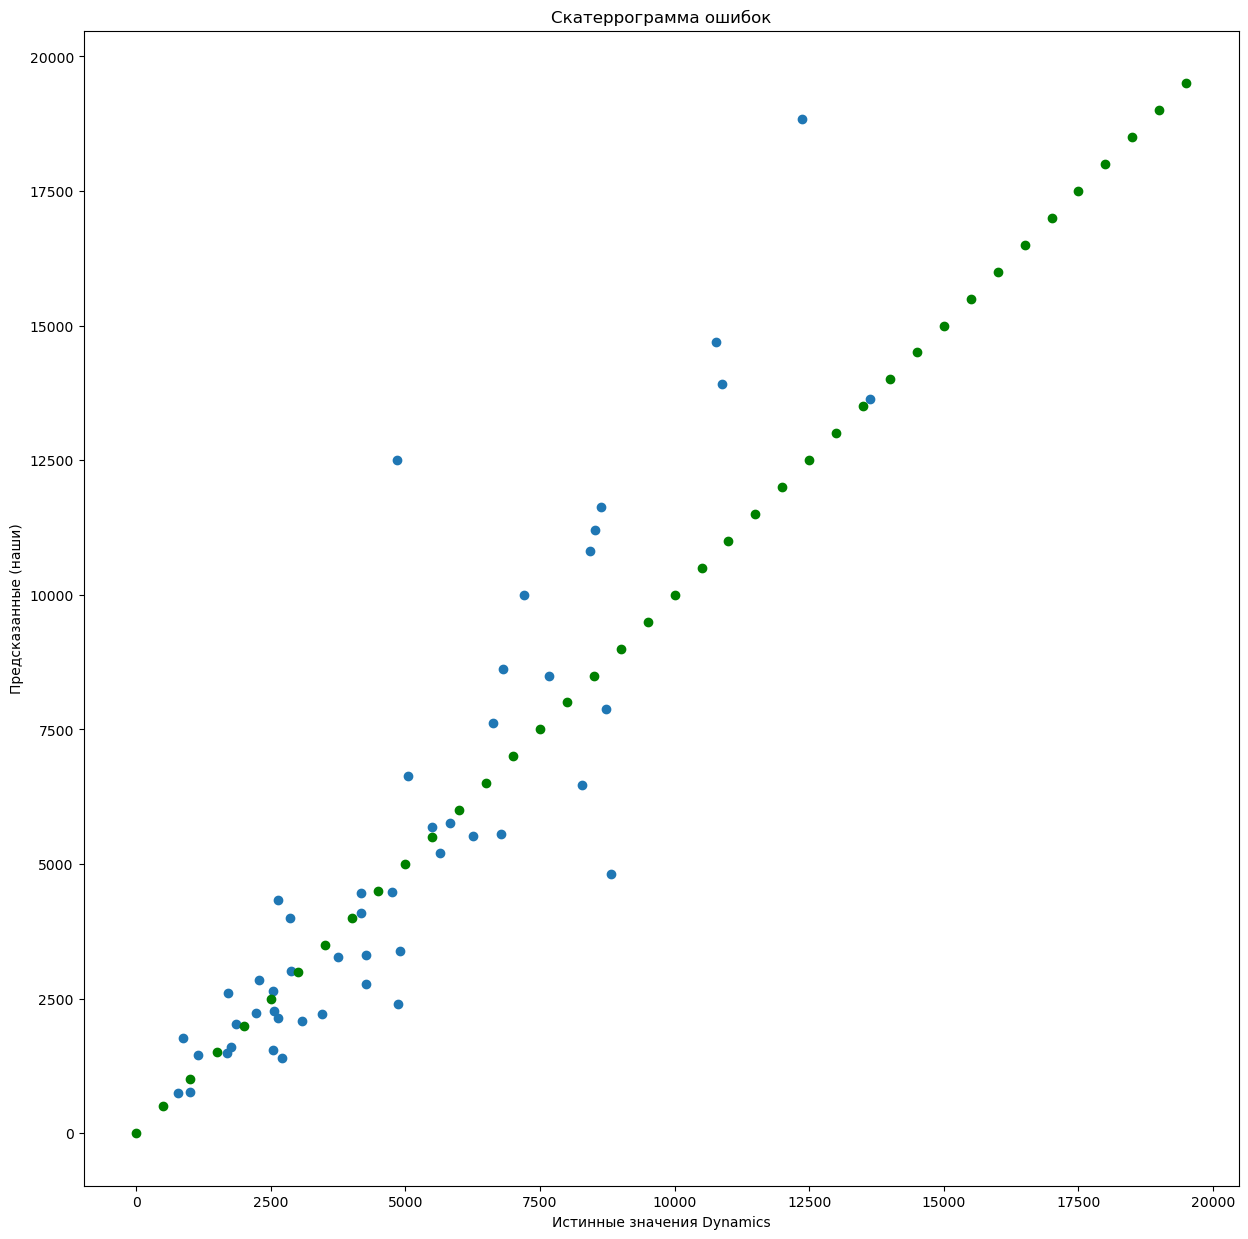

In [80]:
fig, ax = plt.subplots(figsize=(15, 15))
plt.scatter(all_df['TP, мс²/Гц'],all_df['Рассчитанный TP'])
plt.scatter(x=y_eq_x,y=y_eq_x,color='green')
ax.set_aspect('equal', adjustable='box')
plt.xlabel('Истинные значения Dynamics')
plt.ylabel('Предсказанные (наши)')
plt.title('Скатеррограмма ошибок')
plt.show()

In [81]:
all_df.columns

Index(['№', 'ЧССmin, уд./мин.', 'ЧССmax, уд./мин.', 'ЧССavg, уд./мин.',
       'Стресс НС, %', 'SDNN, мс', 'ИН, у.е.', 'Mo, мс', 'RMSSD, мс',
       'NN50, пар', 'pNN50, %', 'HF, мс²/Гц', 'TP, мс²/Гц', 'LF, мс²/Гц',
       'LF/HF, у.е.', 'VLF, мс²/Гц', 'Дата обследования', 'name',
       'Рассчитанный TP', 'Рассчитанный SI'],
      dtype='object')

In [82]:
all_df['Рассчитанный SI'].describe()

count     49.000000
mean      51.503031
std       35.530833
min       10.216505
25%       24.308851
50%       41.221475
75%       67.108594
max      183.416003
Name: Рассчитанный SI, dtype: float64

In [83]:
all_df['Стресс НС, %'].describe()

count    49.000000
mean     53.830612
std      14.338369
min      18.200000
25%      44.500000
50%      54.500000
75%      63.900000
max      83.700000
Name: Стресс НС, %, dtype: float64

In [84]:
print(f"""
    --- ОШИБКИ РАСЧЕТА SI: без выбросов ---
    RMSE {root_mean_squared_error(all_df['Стресс НС, %'],all_df['Рассчитанный SI'])},
    MAE {mean_absolute_error(all_df['Стресс НС, %'],all_df['Рассчитанный SI'])},
    R2 {r2_score(all_df['Стресс НС, %'],all_df['Рассчитанный SI'])},
""")


    --- ОШИБКИ РАСЧЕТА SI: без выбросов ---
    RMSE 39.31665655990916,
    MAE 30.223310139060818,
    R2 -6.675531789873935,



In [85]:
y_eq_x = [i for i in range(0,200,5)]

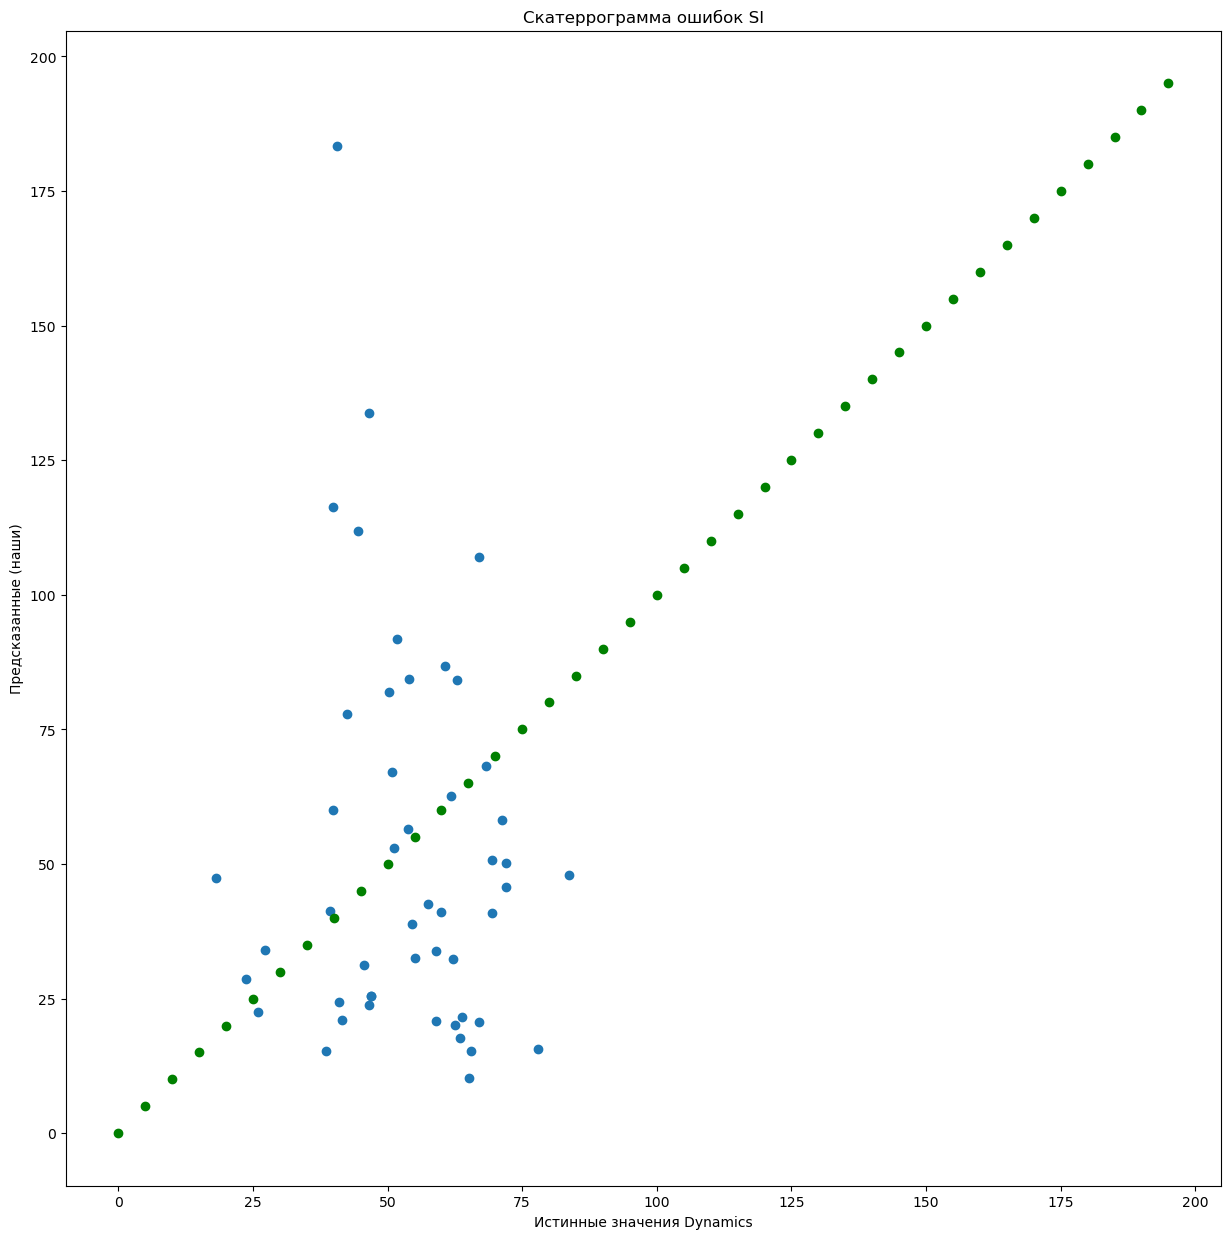

In [86]:
fig, ax = plt.subplots(figsize=(15, 15))
plt.scatter(all_df['Стресс НС, %'],all_df['Рассчитанный SI'])
plt.scatter(x=y_eq_x,y=y_eq_x,color='green')
ax.set_aspect('equal', adjustable='box')
plt.xlabel('Истинные значения Dynamics')
plt.ylabel('Предсказанные (наши)')
plt.title('Скатеррограмма ошибок SI')
plt.show()

#### Выгрузка в файл данных

In [87]:
all_df[['name','Дата обследования','Рассчитанный TP','Рассчитанный SI']].to_csv('../raw_data/sambo_train.csv',index=False)